## 0. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
import pywt
from sklearn.ensemble import IsolationForest, GradientBoostingClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                             mean_squared_error, roc_auc_score, roc_curve)
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# Aesthetics
plt.style.use('dark_background')
PALETTE = ['#00D4FF', '#FF6B35', '#7FFF00', '#FFD700', '#FF69B4', '#9B59B6']
sns.set_palette(PALETTE)

os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print('✅ Environment ready')

✅ Environment ready


## 1. Data Loading & EDA

In [2]:
# ─── Load datasets ───────────────────────────────────────────────────────────
# UPDATE PATHS to your actual file locations
DT_PATH  = 'digitaltwin.csv'   # Bridge Digital Twin (54 cols)
ACC_PATH = 'sensor.csv'                  # Accelerometer / fil2 (7 cols)

dt  = pd.read_csv(DT_PATH,  parse_dates=['Timestamp'])
acc = pd.read_csv(ACC_PATH, parse_dates=['Timestamp'])

print('=== Bridge Digital Twin ===')
print(f'Shape: {dt.shape}  |  Time range: {dt["Timestamp"].min()} → {dt["Timestamp"].max()}')
print('\n=== Accelerometer (fil2) ===')
print(f'Shape: {acc.shape}  |  Time range: {acc["Timestamp"].min()} → {acc["Timestamp"].max()}')

=== Bridge Digital Twin ===
Shape: (43200, 54)  |  Time range: 2023-01-01 00:00:00 → 2023-01-30 23:59:00

=== Accelerometer (fil2) ===
Shape: (1000, 7)  |  Time range: 2025-04-19 00:00:00 → 2025-04-19 00:16:39


In [3]:
dt.head(3)

,Timestamp,Strain_microstrain,Deflection_mm,Vibration_ms2,Tilt_deg,Displacement_mm,Crack_Propagation_mm,Corrosion_Level_percent,Cable_Member_Tension_kN,Bearing_Joint_Forces_kN,...,Soil_Saturation_percent,Landslide_Ground_Movement,Simulated_Slope_Displacement_mm,High_Winds_Storms,Simulated_Wind_Load_Pressure_kPa,Abnormal_Traffic_Load_Surges,Simulated_Localized_Stress_Index,Energy_Harvesting_Potential_W,Estimated_Repair_Cost_USD_incremental,Carbon_Footprint_tCO2e_incremental
0,2023-01-01 00:00:00,NaN,12.663104,1.275955,0.587340,22.576518,-0.000083,0.002910,404.394906,233.052345,...,9.888758,0.0,0.022592,0.0,0.211946,0.0,0.215354,0.081403,1.343588,0.001348
1,2023-01-01 00:01:00,599.936448,12.235297,0.716857,0.657122,21.202649,0.000092,0.004601,367.821051,237.545735,...,9.920331,0.0,0.014647,0.0,0.231188,0.0,0.218747,0.107097,1.397207,0.001299
2,2023-01-01 00:02:00,573.878472,12.447144,0.834753,0.615011,NaN,-0.000377,0.005115,402.393742,239.164832,...,NaN,0.0,0.000000,0.0,0.199192,0.0,0.213449,0.141938,1.318876,0.001378


In [4]:
acc.head(3)

,Timestamp,Accel_X (m/s^2),Accel_Y (m/s^2),Accel_Z (m/s^2),Strain (με),Temp (°C),Condition Label
0,2025-04-19 00:00:00,0.149014,0.419807,9.742482,61.843849,23.704760,0
1,2025-04-19 00:00:01,-0.041479,0.277390,9.795548,82.792300,24.953195,0
2,2025-04-19 00:00:02,0.194307,0.017889,9.730758,91.727889,25.027025,0


In [5]:
# ─── Missing value analysis ───────────────────────────────────────────────────
def missing_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'missing': missing, 'pct': pct})
    report = report[report['missing'] > 0].sort_values('pct', ascending=False)
    print(f'\n{name}: {len(report)} columns with missing values')
    return report

dt_missing  = missing_report(dt,  'Digital Twin')
acc_missing = missing_report(acc, 'Accelerometer')
display(dt_missing.head(15))


Digital Twin: 53 columns with missing values

Accelerometer: 5 columns with missing values


,missing,pct
Vibration_Anomaly_Location,34155,79.06
Strain_microstrain,1821,4.22
Humidity_percent,1783,4.13
Estimated_Repair_Cost_USD_incremental,1771,4.10
Wind_Direction_deg,1768,4.09
Landslide_Ground_Movement,1765,4.09
Abnormal_Traffic_Load_Surges,1763,4.08
High_Winds_Storms,1758,4.07
Vehicle_Load_tons,1756,4.06
Tilt_deg,1753,4.06


In [6]:
# ─── Descriptive statistics for key structural columns ────────────────────────
KEY_STRUCTURAL = [
    'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2',
    'Displacement_mm', 'Crack_Propagation_mm', 'Corrosion_Level_percent',
    'Modal_Frequency_Hz', 'Structural_Health_Index_SHI',
    'Probability_of_Failure_PoF'
]

dt[KEY_STRUCTURAL].describe().T.style.background_gradient(cmap='RdYlGn_r')

,count,mean,std,min,25%,50%,75%,max
Strain_microstrain,41379.000000,851.950836,351.908310,363.529753,618.866446,734.476653,1072.661680,4074.893156
Deflection_mm,41467.000000,15.145403,3.824032,6.889697,12.447132,14.986160,17.090508,30.389080
Vibration_ms2,41478.000000,1.339495,0.979641,0.637735,1.000030,1.198123,1.532924,15.086480
Displacement_mm,41473.000000,22.703596,1.627841,18.964441,21.387484,22.361439,23.985103,27.630262
Crack_Propagation_mm,41494.000000,0.015036,0.009338,-0.001531,0.007511,0.015024,0.022526,0.519706
Corrosion_Level_percent,41531.000000,0.149950,0.086731,-0.010256,0.074979,0.150101,0.224839,0.312679
Modal_Frequency_Hz,41481.000000,1.895313,0.100269,1.353801,1.825477,1.895834,1.968278,2.235211
Structural_Health_Index_SHI,41500.000000,0.815885,0.052818,0.292081,0.797134,0.822936,0.845468,0.907657
Probability_of_Failure_PoF,41456.000000,0.034029,0.017626,0.019160,0.027351,0.030689,0.035370,0.708676


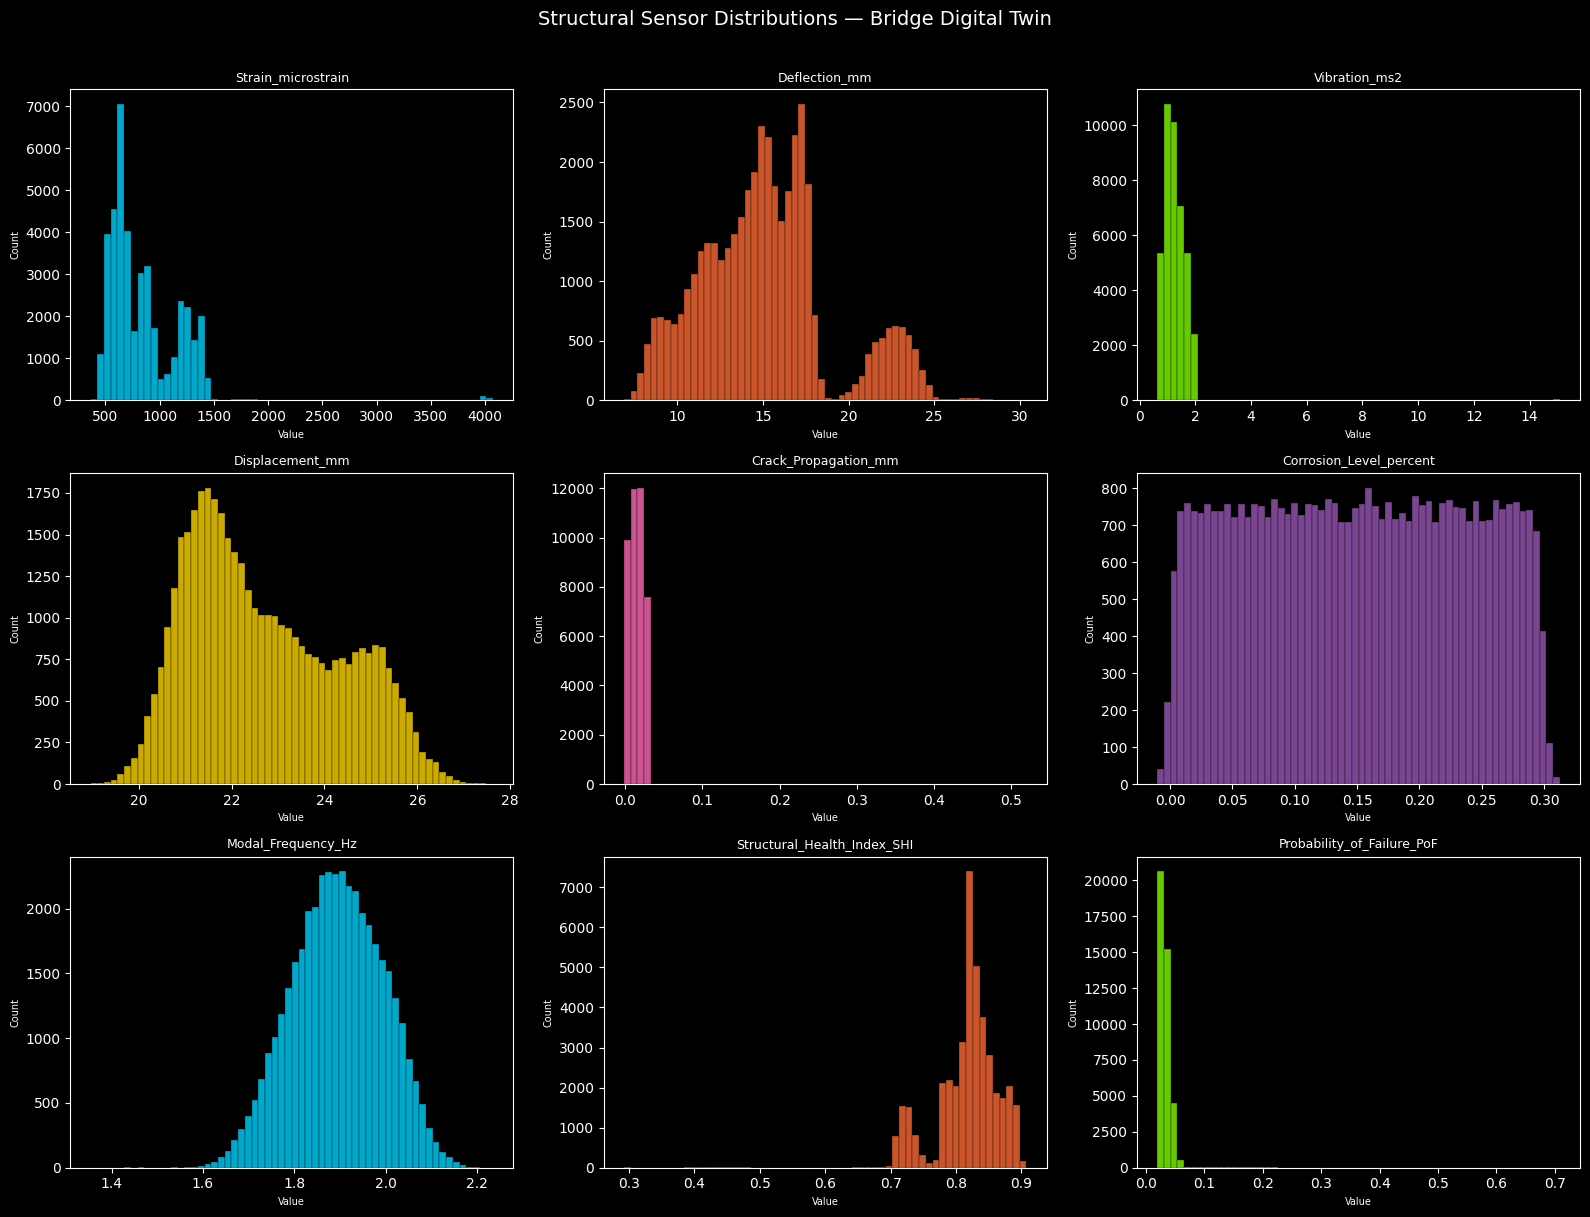

In [7]:
# ─── Distribution plots for structural health indicators ─────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(KEY_STRUCTURAL):
    if col in dt.columns:
        axes[i].hist(dt[col].dropna(), bins=60, color=PALETTE[i % len(PALETTE)], 
                     alpha=0.8, edgecolor='black', linewidth=0.3)
        axes[i].set_title(col, fontsize=9, color='white')
        axes[i].set_xlabel('Value', fontsize=7)
        axes[i].set_ylabel('Count', fontsize=7)

plt.suptitle('Structural Sensor Distributions — Bridge Digital Twin', 
             fontsize=14, color='white', y=1.01)
plt.tight_layout()
plt.savefig('figures/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

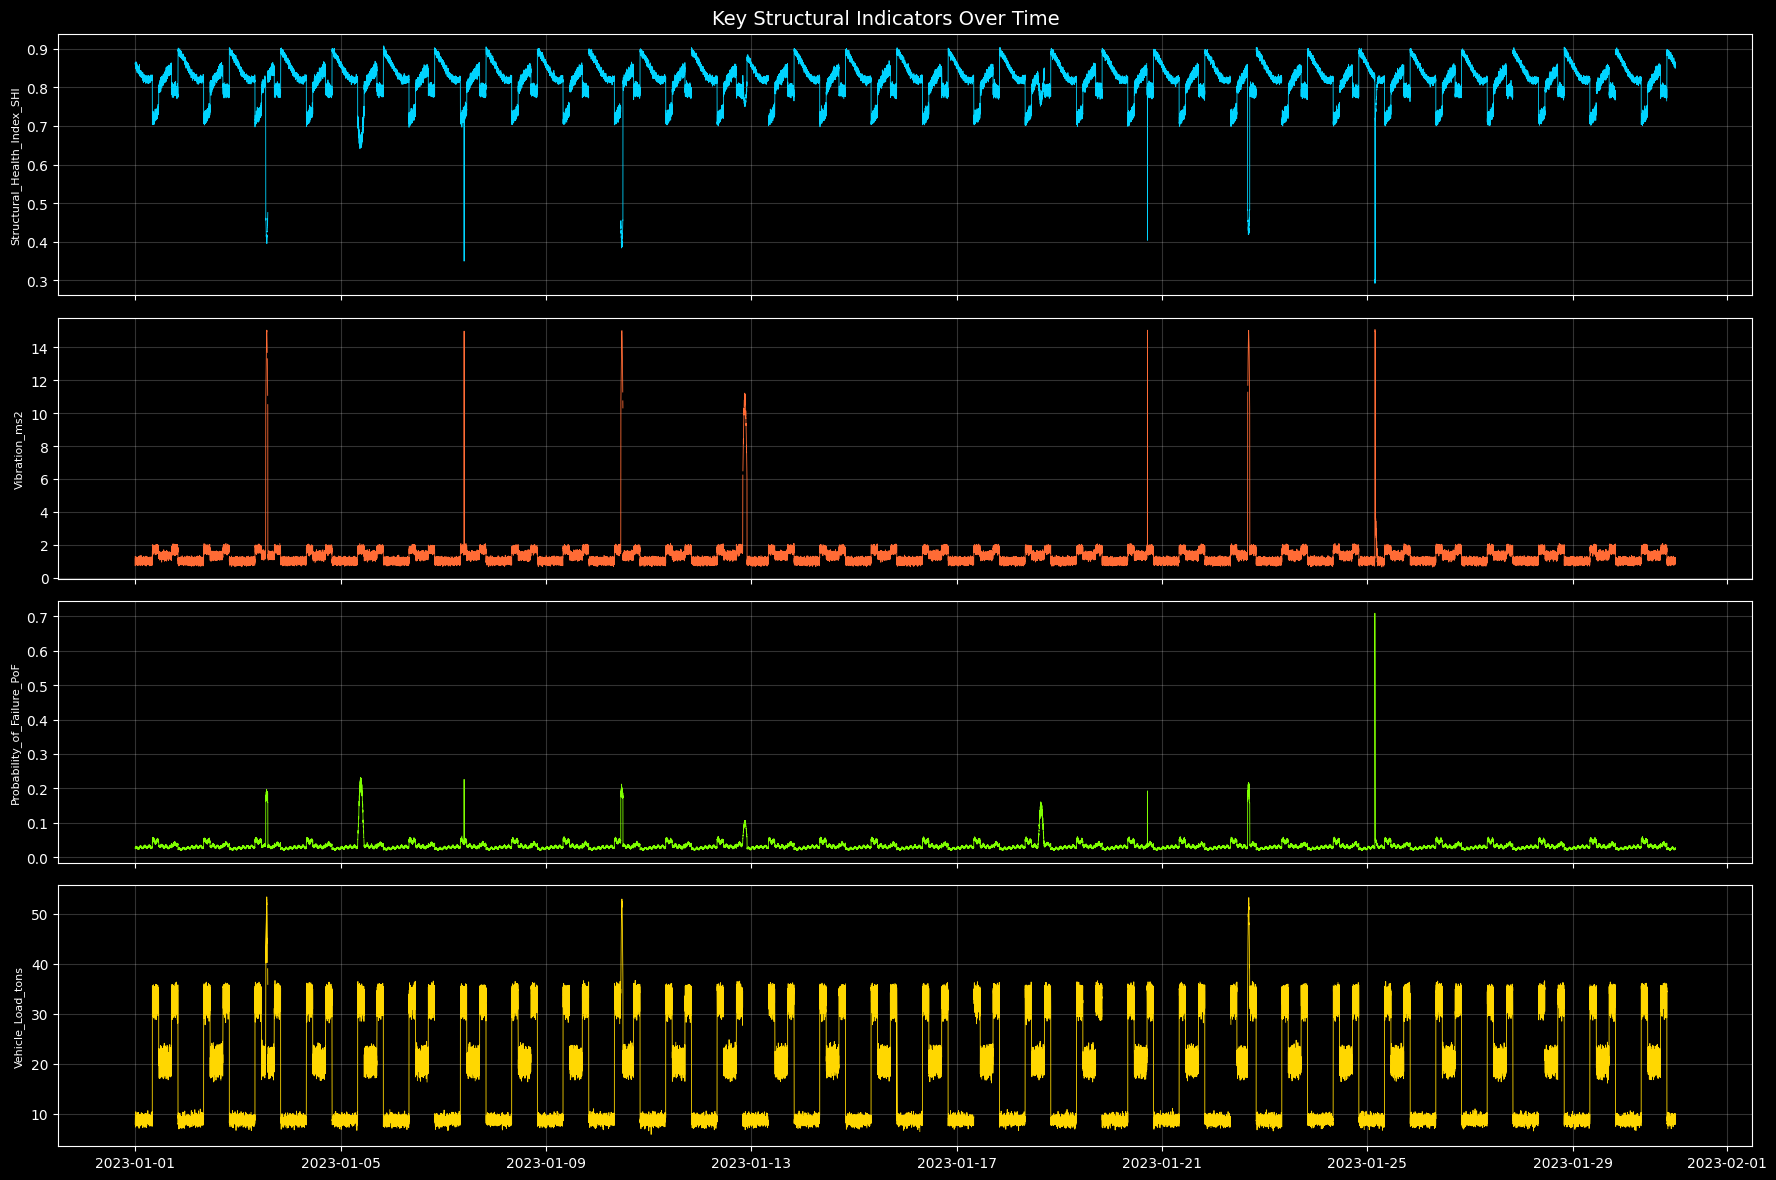

In [8]:
# ─── Time-series overview ─────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)
ts_cols = ['Structural_Health_Index_SHI', 'Vibration_ms2', 
           'Probability_of_Failure_PoF', 'Vehicle_Load_tons']

for ax, col in zip(axes, ts_cols):
    if col in dt.columns:
        ax.plot(dt['Timestamp'], dt[col], linewidth=0.6, color=PALETTE[ts_cols.index(col)])
        ax.set_ylabel(col, fontsize=8)
        ax.grid(alpha=0.2)

plt.suptitle('Key Structural Indicators Over Time', fontsize=14, color='white')
plt.tight_layout()
plt.savefig('figures/timeseries_overview.png', dpi=150, bbox_inches='tight')
plt.show()

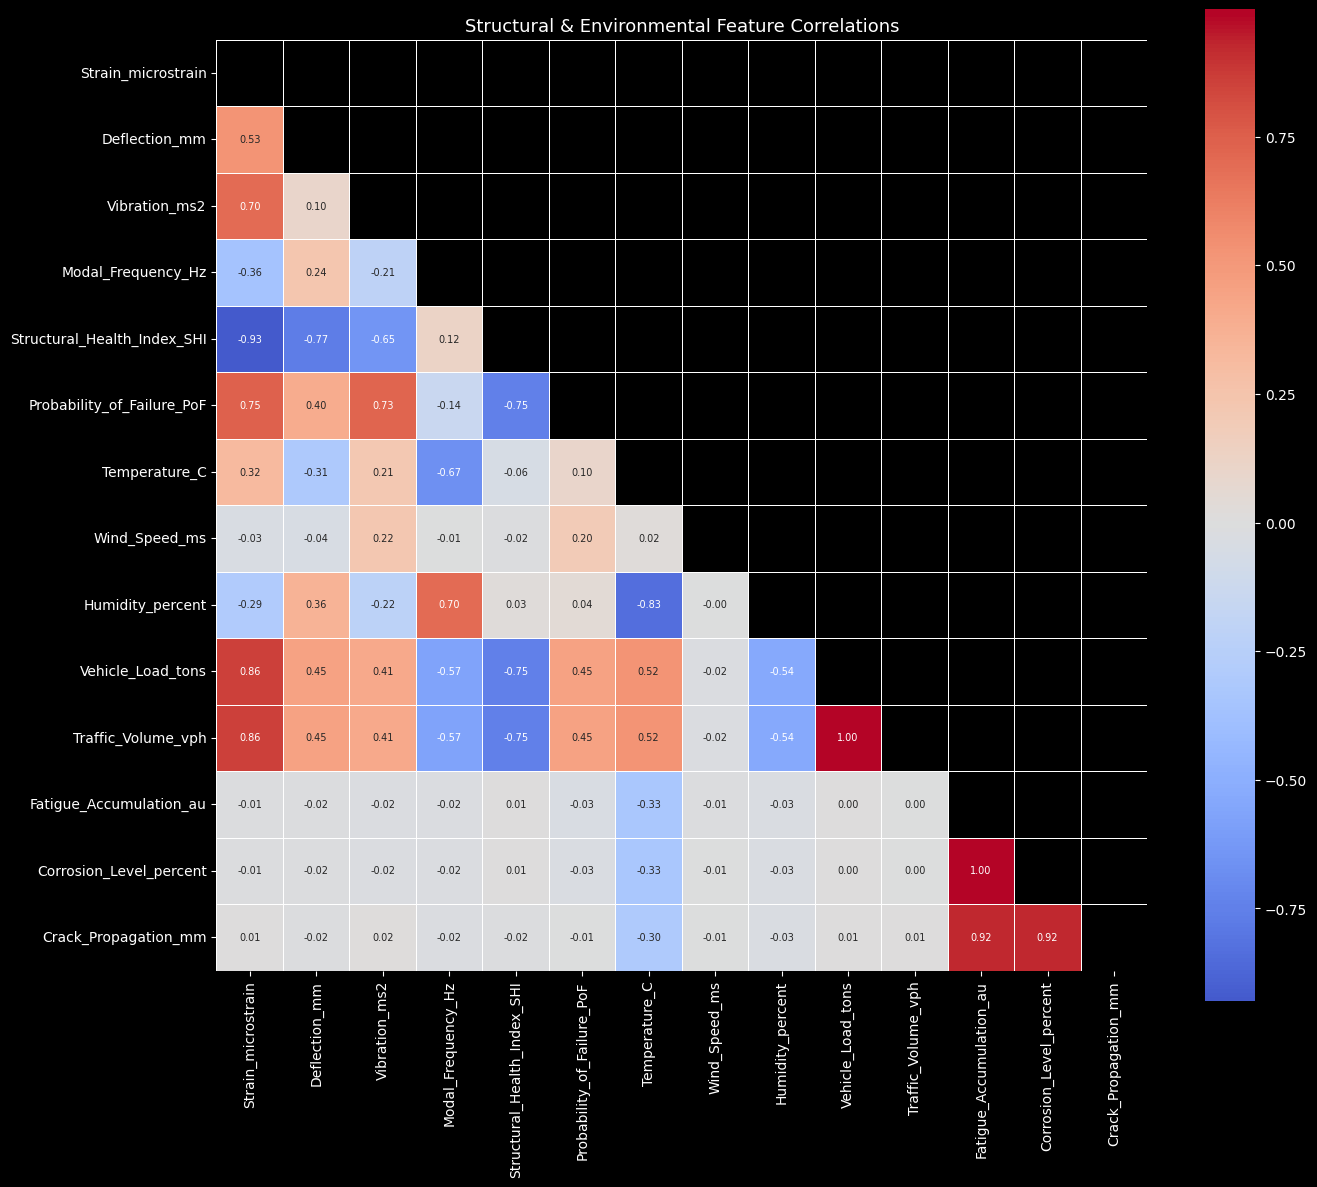

In [9]:
# ─── Correlation heatmap (structural + environmental) ─────────────────────────
CORR_COLS = [
    'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2', 'Modal_Frequency_Hz',
    'Structural_Health_Index_SHI', 'Probability_of_Failure_PoF',
    'Temperature_C', 'Wind_Speed_ms', 'Humidity_percent',
    'Vehicle_Load_tons', 'Traffic_Volume_vph', 'Fatigue_Accumulation_au',
    'Corrosion_Level_percent', 'Crack_Propagation_mm'
]
CORR_COLS = [c for c in CORR_COLS if c in dt.columns]

fig, ax = plt.subplots(figsize=(14, 12))
corr = dt[CORR_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Structural & Environmental Feature Correlations', fontsize=13, color='white')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

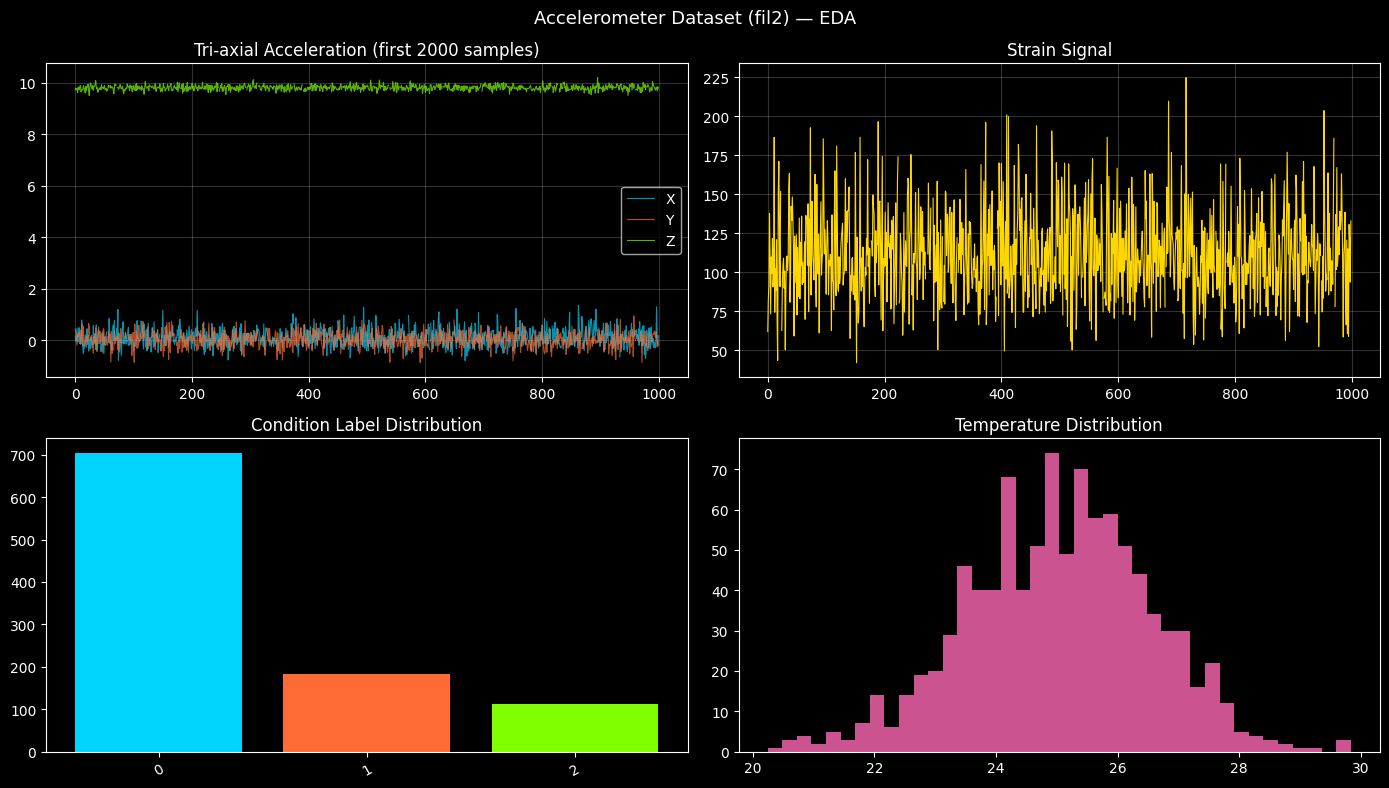

In [10]:
# ─── Accelerometer dataset EDA ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Tri-axial acceleration
for ax_name, col, color in zip(['X','Y','Z'], 
    ['Accel_X (m/s^2)', 'Accel_Y (m/s^2)', 'Accel_Z (m/s^2)'], PALETTE):
    axes[0,0].plot(acc[col].values[:2000], alpha=0.7, label=ax_name, color=color, linewidth=0.8)
axes[0,0].set_title('Tri-axial Acceleration (first 2000 samples)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.2)

# Strain
axes[0,1].plot(acc['Strain (με)'].values[:2000], color=PALETTE[3], linewidth=0.8)
axes[0,1].set_title('Strain Signal')
axes[0,1].grid(alpha=0.2)

# Condition label distribution
if 'Condition Label' in acc.columns:
    label_counts = acc['Condition Label'].value_counts()
    axes[1,0].bar(label_counts.index.astype(str), label_counts.values, color=PALETTE[:len(label_counts)])
    axes[1,0].set_title('Condition Label Distribution')
    axes[1,0].tick_params(axis='x', rotation=30)

# Temperature distribution
axes[1,1].hist(acc['Temp (°C)'].dropna(), bins=40, color=PALETTE[4], alpha=0.8)
axes[1,1].set_title('Temperature Distribution')

plt.suptitle('Accelerometer Dataset (fil2) — EDA', fontsize=13)
plt.tight_layout()
plt.savefig('figures/acc_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Signal Processing — FFT & Wavelet Transform

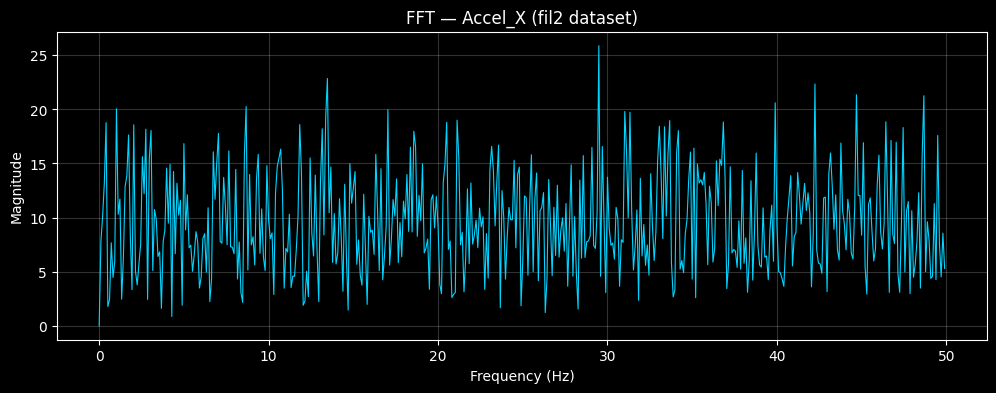

✅ FFT analysis complete


In [11]:
# ─── FFT Analysis ─────────────────────────────────────────────────────────────
def compute_fft(signal_data, fs=100):
    """Compute FFT and return frequencies + magnitudes."""
    N = len(signal_data)
    yf = np.abs(fft(signal_data - signal_data.mean()))[:N//2]
    xf = fftfreq(N, 1/fs)[:N//2]
    return xf, yf

def plot_fft_comparison(signal_clean, signal_damaged, fs=100, title='FFT Comparison'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, sig, label, color in zip(axes, 
        [signal_clean, signal_damaged],
        ['Healthy', 'Anomalous'], 
        [PALETTE[0], PALETTE[1]]):
        xf, yf = compute_fft(np.array(sig), fs)
        ax.plot(xf, yf, color=color, linewidth=0.8)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Magnitude')
        ax.set_title(f'{label} — Frequency Spectrum')
        ax.grid(alpha=0.2)
        # Mark dominant frequencies
        top_freqs = xf[np.argsort(yf)[-5:]]
        for f in top_freqs:
            ax.axvline(f, color='yellow', alpha=0.4, linestyle='--', linewidth=0.8)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    return fig

# Apply to Vibration signal from Digital Twin
if 'Vibration_ms2' in dt.columns and 'Anomaly_Detection_Score' in dt.columns:
    anomaly_thresh = dt['Anomaly_Detection_Score'].quantile(0.90)
    healthy_vib  = dt.loc[dt['Anomaly_Detection_Score'] < anomaly_thresh, 'Vibration_ms2'].dropna()[:1024]
    damaged_vib  = dt.loc[dt['Anomaly_Detection_Score'] >= anomaly_thresh, 'Vibration_ms2'].dropna()[:1024]
    
    if len(healthy_vib) > 64 and len(damaged_vib) > 64:
        fig = plot_fft_comparison(healthy_vib, damaged_vib, 
                                   title='FFT: Healthy vs High-Anomaly Vibration Signals')
        fig.savefig('figures/fft_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()

# Also on accelerometer data
accel_x = acc['Accel_X (m/s^2)'].dropna().values
xf, yf = compute_fft(accel_x[:4096], fs=100)
plt.figure(figsize=(12, 4))
plt.plot(xf, yf, color=PALETTE[0], linewidth=0.8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT — Accel_X (fil2 dataset)')
plt.grid(alpha=0.2)
plt.savefig('figures/fft_accelx.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ FFT analysis complete')

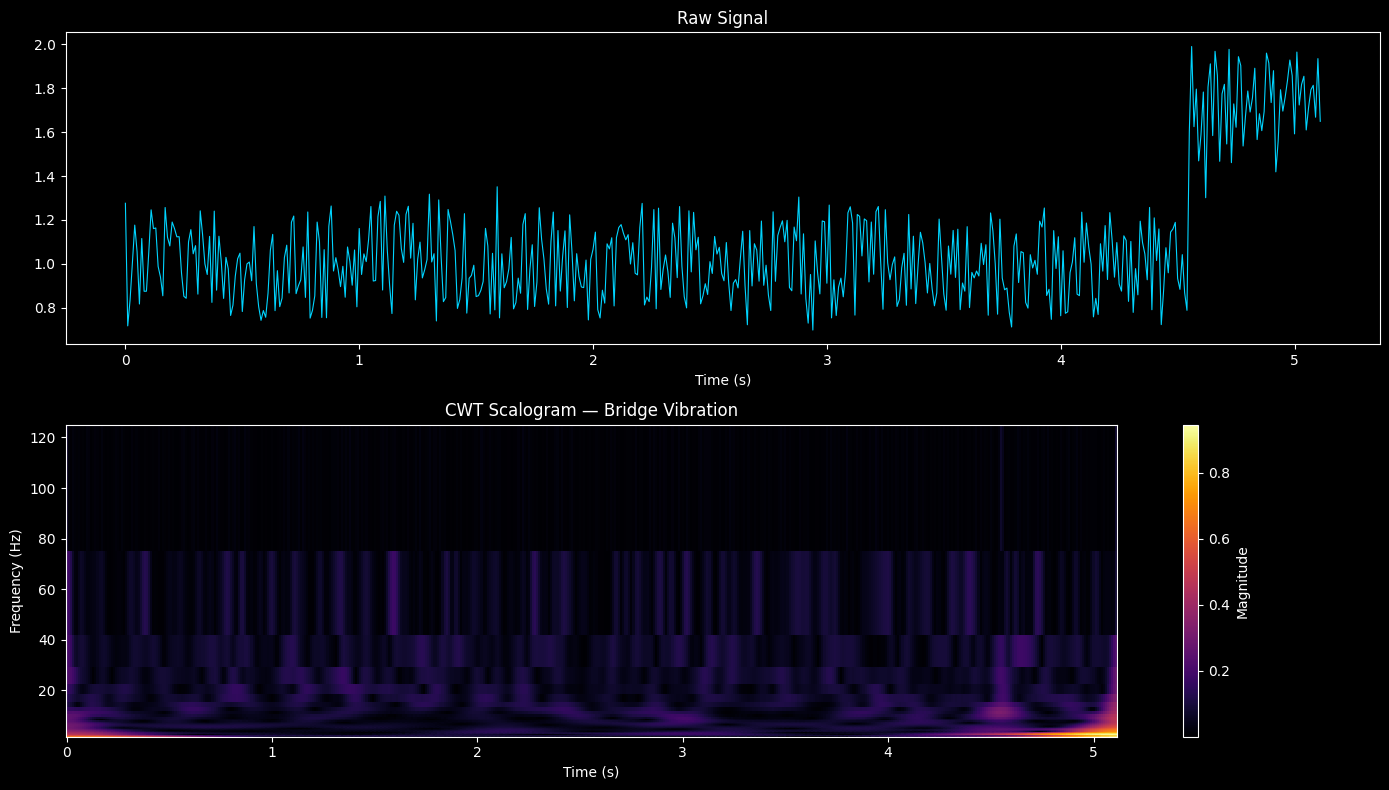

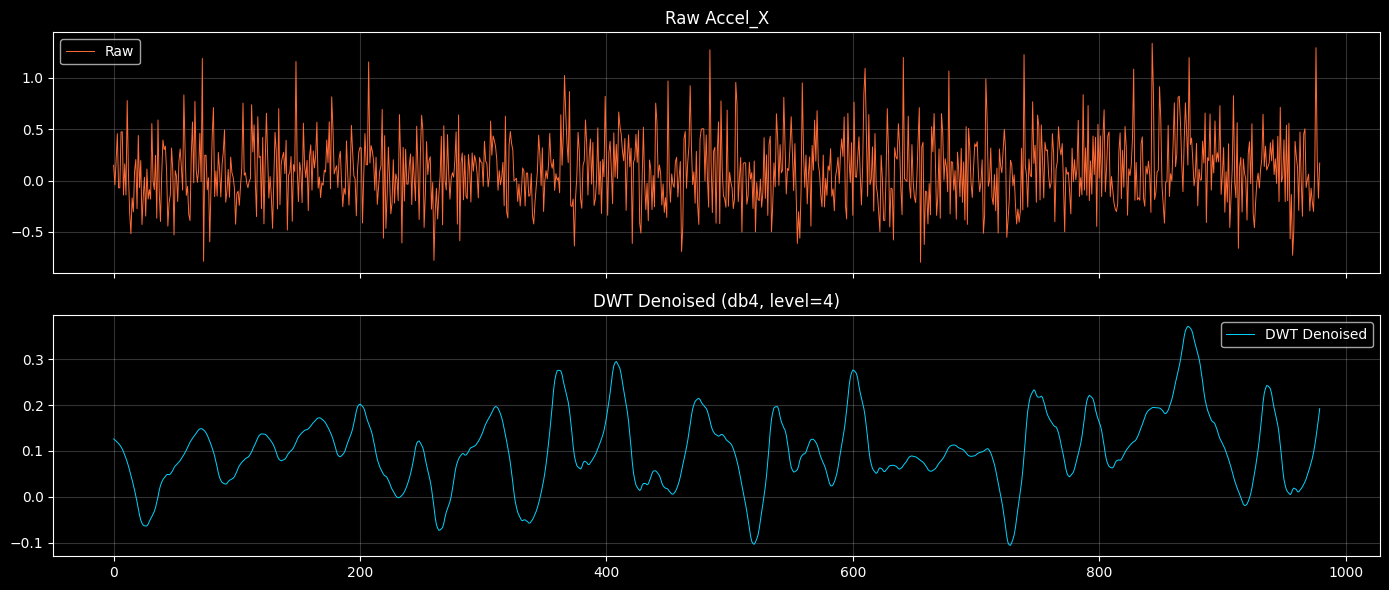

✅ Wavelet analysis complete


In [12]:
# Wavelet Transform (CWT + DWT)
# Reference: IITK Wavelet approach for structural damage detection

# Force-clear any cached version of these functions
for _fn in ['plot_cwt', 'dwt_denoise', 'extract_dwt_energy']:
    if _fn in dir():
        del globals()[_fn]

def plot_cwt(sig, fs=100, wavelet='cmor1.5-1.0', title='CWT Scalogram'):
    """Continuous Wavelet Transform scalogram."""
    sig = np.array(sig[:512], dtype=float)  # copy + cast ensures writeable
    widths = np.arange(1, 64)
    cwtmatr, freqs = pywt.cwt(sig, widths, wavelet, sampling_period=1/fs)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    t = np.arange(len(sig)) / fs
    axes[0].plot(t, sig, color=PALETTE[0], linewidth=0.8)
    axes[0].set_title('Raw Signal')
    axes[0].set_xlabel('Time (s)')
    
    im = axes[1].pcolormesh(t, freqs, np.abs(cwtmatr), cmap='inferno', shading='auto')
    axes[1].set_ylabel('Frequency (Hz)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_title(title)
    plt.colorbar(im, ax=axes[1], label='Magnitude')
    plt.tight_layout()
    return fig

def dwt_denoise(sig, wavelet='db4', level=4, threshold_mode='soft'):
    """DWT-based denoising for sensor signals."""
    sig = np.array(sig, dtype=float)  # dtype cast forces a writable copy
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    sigma  = np.median(np.abs(coeffs[-1])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(sig)))
    denoised_coeffs = [coeffs[0]] + [
        pywt.threshold(c, uthresh, mode=threshold_mode) for c in coeffs[1:]
    ]
    return pywt.waverec(denoised_coeffs, wavelet)

def extract_dwt_energy(sig, wavelet='db4', level=5):
    """Extract energy from each DWT decomposition level — damage indicator."""
    coeffs = pywt.wavedec(np.array(sig, dtype=float), wavelet, level=level)
    energies = [np.sum(c**2) for c in coeffs]
    total = sum(energies)
    return [e/total for e in energies]

# Apply CWT to vibration signal
if 'Vibration_ms2' in dt.columns:
    vib_sample = np.array(dt['Vibration_ms2'].dropna().values[:512], dtype=float)
    fig = plot_cwt(vib_sample, title='CWT Scalogram — Bridge Vibration')
    fig.savefig('figures/cwt_vibration.png', dpi=150, bbox_inches='tight')
    plt.show()

# DWT denoising comparison
accel_raw = np.array(acc['Accel_X (m/s^2)'].dropna().values[:1024], dtype=float)
accel_clean = dwt_denoise(accel_raw)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(accel_raw, color=PALETTE[1], linewidth=0.7, label='Raw')
axes[0].set_title('Raw Accel_X')
axes[0].legend()
axes[1].plot(accel_clean[:len(accel_raw)], color=PALETTE[0], linewidth=0.7, label='DWT Denoised')
axes[1].set_title('DWT Denoised (db4, level=4)')
axes[1].legend()
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('figures/dwt_denoising.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Wavelet analysis complete')

## 3. Feature Engineering

In [13]:
# ─── Time-domain features from sliding windows ────────────────────────────────

def time_domain_features(window):
    """Statistical features from a signal window."""
    w = np.array(window)
    rms   = np.sqrt(np.mean(w**2))
    crest = np.max(np.abs(w)) / (rms + 1e-9)
    kurt  = pd.Series(w).kurt()
    skew  = pd.Series(w).skew()
    return {
        'mean': np.mean(w),
        'std':  np.std(w),
        'rms':  rms,
        'max':  np.max(w),
        'min':  np.min(w),
        'p2p':  np.ptp(w),   # peak-to-peak
        'crest_factor': crest,
        'kurtosis': kurt,
        'skewness': skew,
        'shape_factor': rms / (np.mean(np.abs(w)) + 1e-9)
    }

def freq_domain_features(window, fs=100):
    """Frequency-domain features from a signal window."""
    w = np.array(window)
    N = len(w)
    yf = np.abs(fft(w - w.mean()))[:N//2]
    xf = fftfreq(N, 1/fs)[:N//2]
    
    total_power = np.sum(yf**2) + 1e-9
    dominant_freq = xf[np.argmax(yf)]
    
    # Band power (typical civil engineering frequency bands)
    def band_power(f_low, f_high):
        mask = (xf >= f_low) & (xf <= f_high)
        return np.sum(yf[mask]**2) / total_power
    
    return {
        'dominant_freq': dominant_freq,
        'spectral_centroid': np.sum(xf * yf**2) / total_power,
        'spectral_entropy': -np.sum((yf**2/total_power+1e-10)*np.log(yf**2/total_power+1e-10)),
        'band_power_0_5':   band_power(0, 5),
        'band_power_5_15':  band_power(5, 15),
        'band_power_15_50': band_power(15, 50),
    }

def wavelet_features(window, wavelet='db4', level=4):
    """DWT energy per level as features."""
    energies = extract_dwt_energy(window, wavelet=wavelet, level=level)
    return {f'dwt_energy_L{i}': e for i, e in enumerate(energies)}

def extract_window_features(sig, window_size=256, hop=128, fs=100):
    """Sliding window feature extraction."""
    features = []
    indices  = []
    for start in range(0, len(sig) - window_size, hop):
        w = sig[start:start+window_size]
        row = {}
        row.update(time_domain_features(w))
        row.update(freq_domain_features(w, fs))
        row.update(wavelet_features(w))
        features.append(row)
        indices.append(start + window_size//2)
    return pd.DataFrame(features, index=indices)

# Extract features from Vibration signal (DT dataset)
print('Extracting features from Vibration_ms2...')
vib_sig = dt['Vibration_ms2'].ffill().values
vib_features = extract_window_features(vib_sig, window_size=256, hop=128)
print(f'Vibration features shape: {vib_features.shape}')

# Extract features from accelerometer dataset
print('Extracting features from Accel_X...')
acc_sig = acc['Accel_X (m/s^2)'].ffill().values
acc_features = extract_window_features(acc_sig, window_size=256, hop=128)
print(f'Accel features shape: {acc_features.shape}')
vib_features.head(3)

Extracting features from Vibration_ms2...
Vibration features shape: (336, 21)
Extracting features from Accel_X...
Accel features shape: (6, 21)


,mean,std,rms,max,min,p2p,crest_factor,kurtosis,skewness,shape_factor,...,spectral_centroid,spectral_entropy,band_power_0_5,band_power_5_15,band_power_15_50,dwt_energy_L0,dwt_energy_L1,dwt_energy_L2,dwt_energy_L3,dwt_energy_L4
128,1.002730,0.155651,1.014739,1.351079,0.716857,0.634222,1.331454,-1.070652,0.114527,1.011976,...,23.956611,4.406229,0.132433,0.182113,0.685453,0.983597,0.000695,0.001752,0.005273,0.008683
256,0.997758,0.153769,1.009537,1.351079,0.697829,0.653250,1.338315,-1.067983,0.175086,1.011806,...,24.584967,4.546946,0.107766,0.222348,0.669886,0.983556,0.000787,0.002664,0.003597,0.009395
384,1.087814,0.284615,1.124431,1.990632,0.697829,1.292803,1.770347,1.792703,1.437976,1.033661,...,8.998604,3.300021,0.656700,0.134994,0.208307,0.984776,0.000820,0.004020,0.003178,0.007206


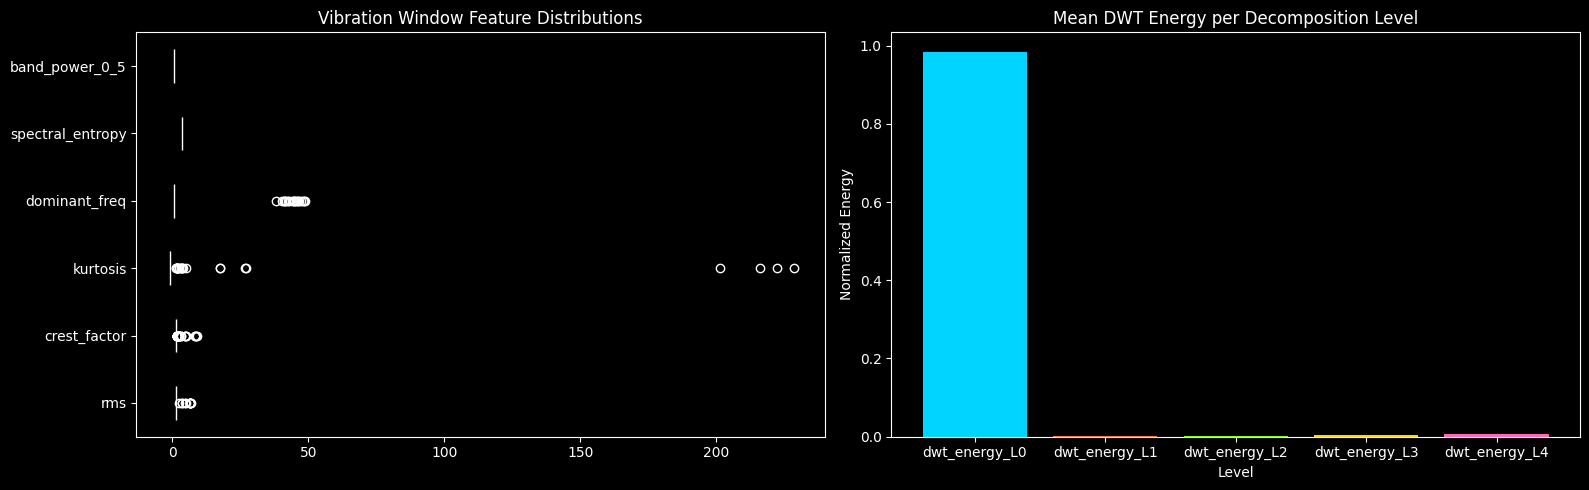

✅ Feature engineering complete


In [14]:
# ─── Feature importance overview (visualize) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vib_features.boxplot(ax=axes[0], vert=False, 
                     column=['rms','crest_factor','kurtosis','dominant_freq',
                             'spectral_entropy','band_power_0_5'],
                     grid=False)
axes[0].set_title('Vibration Window Feature Distributions')

# DWT energy profile
dwt_cols = [c for c in vib_features.columns if 'dwt_energy' in c]
axes[1].bar(dwt_cols, vib_features[dwt_cols].mean(), color=PALETTE[:len(dwt_cols)])
axes[1].set_title('Mean DWT Energy per Decomposition Level')
axes[1].set_xlabel('Level')
axes[1].set_ylabel('Normalized Energy')

plt.tight_layout()
plt.savefig('figures/feature_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature engineering complete')

## 4. Dataset Fusion Strategy

In [15]:
# ─── Fusion: align fil2 (high-freq accelerometer) → Digital Twin timestamps ──
#
# Strategy:
#  1. Resample fil2 to match DT frequency using time-indexed aggregation
#  2. Compute window features per DT interval from fil2
#  3. Merge on nearest Timestamp
#  4. Impute remaining nulls

def fuse_datasets(dt_df, acc_df, resample_rule='1T'):
    """
    Fuse Digital Twin and Accelerometer datasets.
    resample_rule: pandas frequency string matching DT cadence
    """
    # Set timestamp as index
    dt_ts  = dt_df.set_index('Timestamp').copy()
    acc_ts = acc_df.set_index('Timestamp').copy()
    
    # Encode condition label if present
    if 'Condition Label' in acc_ts.columns:
        le = LabelEncoder()
        acc_ts['Condition_encoded'] = le.fit_transform(acc_ts['Condition Label'].astype(str))
        acc_ts = acc_ts.drop(columns=['Condition Label'])
    
    # Resample acc data to match DT intervals
    acc_numeric = acc_ts.select_dtypes(include=[np.number])
    
    # Aggregate: mean for most signals, std for variability (structural insight)
    acc_resampled_mean = acc_numeric.resample(resample_rule).mean()
    acc_resampled_std  = acc_numeric.resample(resample_rule).std()
    acc_resampled_std.columns = [f'{c}_std' for c in acc_resampled_std.columns]
    acc_resampled_max  = acc_numeric.resample(resample_rule).max()
    acc_resampled_max.columns = [f'{c}_max' for c in acc_resampled_max.columns]
    
    acc_combined = pd.concat([acc_resampled_mean, acc_resampled_std, acc_resampled_max], axis=1)
    
    # Merge with DT on nearest timestamp
    fused = pd.merge_asof(
        dt_ts.sort_index().reset_index(),
        acc_combined.sort_index().reset_index(),
        on='Timestamp',
        direction='nearest',
        tolerance=pd.Timedelta('5min')
    )
    
    return fused

# Detect DT cadence
dt_freq = pd.infer_freq(dt['Timestamp'].sort_values())
print(f'Detected DT frequency: {dt_freq}')

# Auto-set resample rule
resample_rule = '1T' if dt_freq is None else dt_freq
print(f'Using resample rule: {resample_rule}')

fused = fuse_datasets(dt, acc, resample_rule=resample_rule)
print(f'\nFused dataset shape: {fused.shape}')
print(f'Missing after fusion: {fused.isnull().sum().sum()} total nulls')
fused.head(2)

Detected DT frequency: min
Using resample rule: min

Fused dataset shape: (43200, 72)
Missing after fusion: 901394 total nulls


,Timestamp,Strain_microstrain,Deflection_mm,Vibration_ms2,Tilt_deg,Displacement_mm,Crack_Propagation_mm,Corrosion_Level_percent,Cable_Member_Tension_kN,Bearing_Joint_Forces_kN,...,Accel_Z (m/s^2)_std,Strain (με)_std,Temp (°C)_std,Condition_encoded_std,Accel_X (m/s^2)_max,Accel_Y (m/s^2)_max,Accel_Z (m/s^2)_max,Strain (με)_max,Temp (°C)_max,Condition_encoded_max
0,2023-01-01 00:00:00,NaN,12.663104,1.275955,0.587340,22.576518,-0.000083,0.002910,404.394906,233.052345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-01 00:01:00,599.936448,12.235297,0.716857,0.657122,21.202649,0.000092,0.004601,367.821051,237.545735,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# ─── Imputation & cleaning ────────────────────────────────────────────────────
# Numerical: forward-fill → backward-fill → median
numeric_cols = fused.select_dtypes(include=[np.number]).columns

fused[numeric_cols] = fused[numeric_cols].ffill().bfill()
for col in numeric_cols:
    fused[col] = fused[col].fillna(fused[col].median())

# Handle categorical/string columns
for col in fused.select_dtypes(include=['object']).columns:
    if col not in ['Timestamp', 'Maintenance_Alert', 'Vibration_Anomaly_Location', 
                   'Localized_Strain_Hotspot']:
        fused[col] = fused[col].fillna('Unknown')

print(f'Remaining nulls: {fused.isnull().sum().sum()}')

# Save fused dataset
fused.to_csv('bridge_fused.csv', index=False)
print(f'✅ Fused dataset saved: bridge_fused.csv ({fused.shape[0]} rows × {fused.shape[1]} cols)')

Remaining nulls: 811755


✅ Fused dataset saved: bridge_fused.csv (43200 rows × 72 cols)


In [17]:
# ─── Feature selection for ML ─────────────────────────────────────────────────
# Drop: timestamp, ID-like columns, target leakage columns
EXCLUDE = [
    'Timestamp', 'Maintenance_Alert', 'Vibration_Anomaly_Location',
    'Localized_Strain_Hotspot', 'SHI_Predicted_24h_Ahead',
    'SHI_Predicted_7d_Ahead', 'SHI_Predicted_30d_Ahead',
    'Bridge_Mood_Meter'  # drop non-engineering feature
]

TARGETS = {
    'anomaly_binary':    'Anomaly_Detection_Score',   # threshold → binary
    'pof':               'Probability_of_Failure_PoF',
    'shi':               'Structural_Health_Index_SHI',
    'maintenance_alert': 'Maintenance_Alert',
}

feature_cols = [c for c in fused.select_dtypes(include=[np.number]).columns 
                if c not in EXCLUDE 
                and c not in TARGETS.values()
                and c != 'Anomaly_Detection_Score']

print(f'Feature columns: {len(feature_cols)}')
print(feature_cols[:20])

Feature columns: 61
['Strain_microstrain', 'Deflection_mm', 'Vibration_ms2', 'Tilt_deg', 'Displacement_mm', 'Crack_Propagation_mm', 'Corrosion_Level_percent', 'Cable_Member_Tension_kN', 'Bearing_Joint_Forces_kN', 'Fatigue_Accumulation_au', 'Modal_Frequency_Hz', 'Temperature_C', 'Humidity_percent', 'Wind_Speed_ms', 'Wind_Direction_deg', 'Precipitation_mmh', 'Water_Level_m', 'Seismic_Activity_ms2', 'Solar_Radiation_Wm2', 'Air_Quality_Index_AQI']


## 5. Anomaly Detection

In [18]:
# ─── 5a. Isolation Forest ─────────────────────────────────────────────────────

ANOMALY_FEATURES = [
    'Vibration_ms2', 'Strain_microstrain', 'Deflection_mm',
    'Displacement_mm', 'Modal_Frequency_Hz', 'Temperature_C',
    'Wind_Speed_ms', 'Crack_Propagation_mm'
]
ANOMALY_FEATURES = [f for f in ANOMALY_FEATURES if f in fused.columns]

X_anom = fused[ANOMALY_FEATURES].dropna()

scaler_anom = StandardScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

iso_forest = IsolationForest(
    n_estimators=200, 
    contamination=0.05,   # ~5% expected anomaly rate
    max_samples='auto',
    random_state=SEED,
    n_jobs=-1
)
iso_preds = iso_forest.fit_predict(X_anom_scaled)
iso_scores = iso_forest.decision_function(X_anom_scaled)

fused_anom = fused.loc[X_anom.index].copy()
fused_anom['IF_label']  = iso_preds          # -1 = anomaly, 1 = normal
fused_anom['IF_score']  = iso_scores

n_anomalies = (iso_preds == -1).sum()
print(f'Isolation Forest: {n_anomalies} anomalies detected ({n_anomalies/len(iso_preds)*100:.1f}%)')

# Save model
joblib.dump(iso_forest, 'models/isolation_forest.pkl')
joblib.dump(scaler_anom, 'models/scaler_anomaly.pkl')
print('✅ Isolation Forest saved')

Isolation Forest: 2160 anomalies detected (5.0%)
✅ Isolation Forest saved


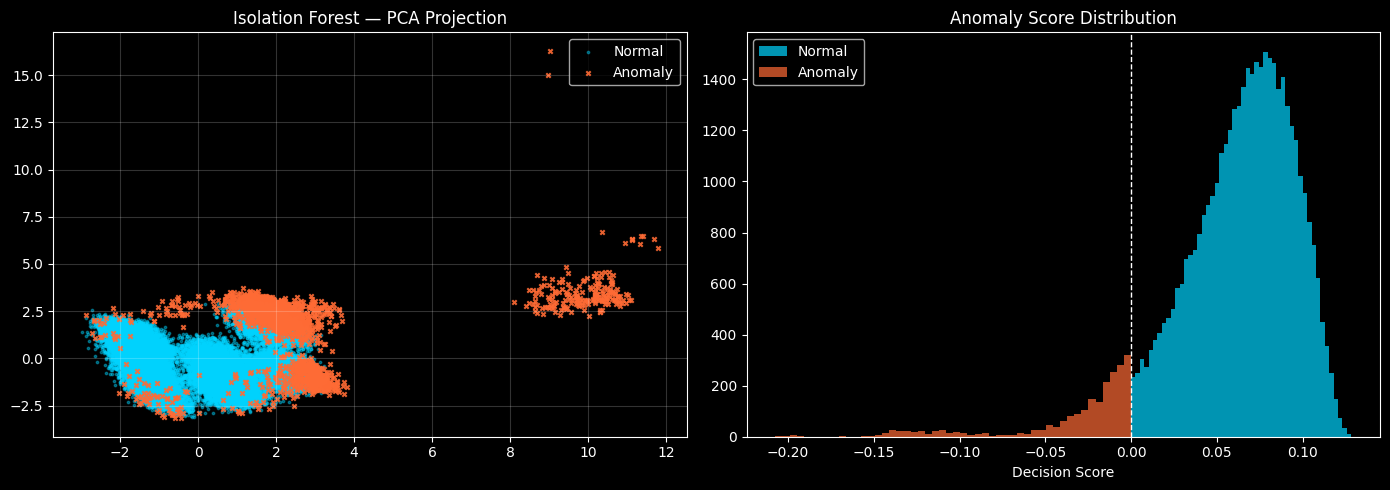

In [19]:
# ─── Isolation Forest visualization ──────────────────────────────────────────
# PCA projection to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_anom_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomaly scatter
normal  = iso_preds == 1
anomaly = iso_preds == -1
axes[0].scatter(X_pca[normal, 0],  X_pca[normal, 1],  
                c=PALETTE[0], s=3, alpha=0.4, label='Normal')
axes[0].scatter(X_pca[anomaly, 0], X_pca[anomaly, 1], 
                c=PALETTE[1], s=10, alpha=0.9, label='Anomaly', marker='x')
axes[0].set_title('Isolation Forest — PCA Projection')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Score distribution
axes[1].hist(iso_scores[normal],  bins=50, color=PALETTE[0], alpha=0.7, label='Normal')
axes[1].hist(iso_scores[anomaly], bins=50, color=PALETTE[1], alpha=0.7, label='Anomaly')
axes[1].axvline(0, color='white', linestyle='--', linewidth=1)
axes[1].set_title('Anomaly Score Distribution')
axes[1].set_xlabel('Decision Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ─── 5b. Autoencoder for Anomaly Detection ───────────────────────────────────

class StructuralAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

def train_autoencoder(X_train, epochs=50, batch_size=64, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    X_tensor = torch.FloatTensor(X_train).to(device)
    dataset  = TensorDataset(X_tensor)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    model = StructuralAutoencoder(X_train.shape[1], latent_dim=8).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    losses = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            optimizer.zero_grad()
            recon = model(batch)
            loss  = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | Loss: {losses[-1]:.6f}')
    
    return model, losses, device

# Train on normal data only (unsupervised)
X_normal = X_anom_scaled[iso_preds == 1]  # use IF-normal samples for training
model_ae, losses_ae, device = train_autoencoder(X_normal, epochs=50)

# Compute reconstruction errors for all samples
model_ae.eval()
with torch.no_grad():
    X_t = torch.FloatTensor(X_anom_scaled).to(device)
    recon = model_ae(X_t).cpu().numpy()

recon_errors = np.mean((X_anom_scaled - recon)**2, axis=1)
ae_threshold = np.percentile(recon_errors[iso_preds == 1], 95)  # 95th pct of normal
ae_anomalies = recon_errors > ae_threshold

print(f'\nAutoencoder threshold (95th pct): {ae_threshold:.4f}')
print(f'Autoencoder anomalies: {ae_anomalies.sum()} ({ae_anomalies.mean()*100:.1f}%)')

# Combined anomaly: flagged by BOTH methods
fused_anom['AE_anomaly']       = ae_anomalies
fused_anom['AE_recon_error']   = recon_errors
fused_anom['consensus_anomaly'] = (iso_preds == -1) & ae_anomalies
print(f'Consensus anomalies (IF + AE): {fused_anom["consensus_anomaly"].sum()}')

torch.save(model_ae.state_dict(), 'models/autoencoder.pt')
print('✅ Autoencoder saved')

Epoch  10/50 | Loss: 0.060553


Epoch  20/50 | Loss: 0.054556


Epoch  30/50 | Loss: 0.048003


Epoch  40/50 | Loss: 0.045085


Epoch  50/50 | Loss: 0.044247

Autoencoder threshold (95th pct): 0.0411
Autoencoder anomalies: 2866 (6.6%)
Consensus anomalies (IF + AE): 814
✅ Autoencoder saved


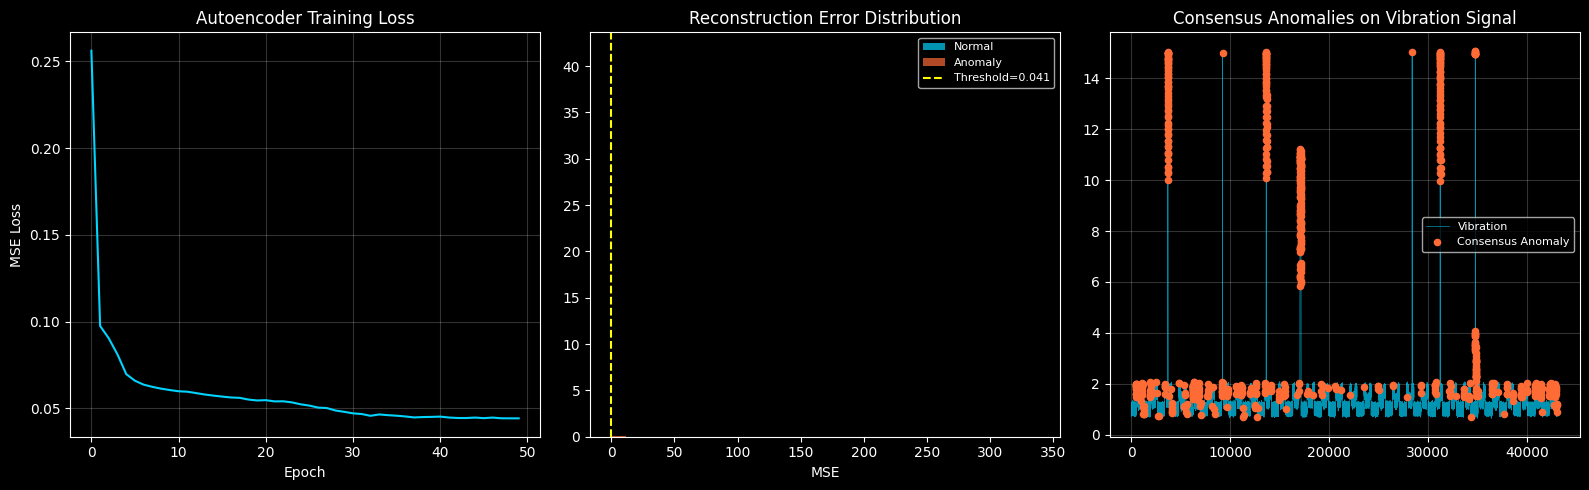

In [21]:
# ─── Autoencoder visualizations ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Training loss
axes[0].plot(losses_ae, color=PALETTE[0], linewidth=1.5)
axes[0].set_title('Autoencoder Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(alpha=0.2)

# Reconstruction error distribution
axes[1].hist(recon_errors[~ae_anomalies], bins=60, color=PALETTE[0], alpha=0.7, label='Normal', density=True)
axes[1].hist(recon_errors[ae_anomalies],  bins=30, color=PALETTE[1], alpha=0.7, label='Anomaly', density=True)
axes[1].axvline(ae_threshold, color='yellow', linestyle='--', linewidth=1.5, label=f'Threshold={ae_threshold:.3f}')
axes[1].set_title('Reconstruction Error Distribution')
axes[1].set_xlabel('MSE')
axes[1].legend(fontsize=8)

# Consensus anomalies on key feature
if 'Vibration_ms2' in fused_anom.columns:
    t = np.arange(len(fused_anom))
    axes[2].plot(t, fused_anom['Vibration_ms2'].values, color=PALETTE[0], linewidth=0.5, alpha=0.7, label='Vibration')
    cons_idx = fused_anom['consensus_anomaly'].values
    axes[2].scatter(t[cons_idx], fused_anom['Vibration_ms2'].values[cons_idx],
                    color=PALETTE[1], s=20, zorder=5, label='Consensus Anomaly')
    axes[2].set_title('Consensus Anomalies on Vibration Signal')
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('figures/autoencoder_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Operational Modal Analysis (SSI-inspired)

Identified natural frequencies: [] Hz


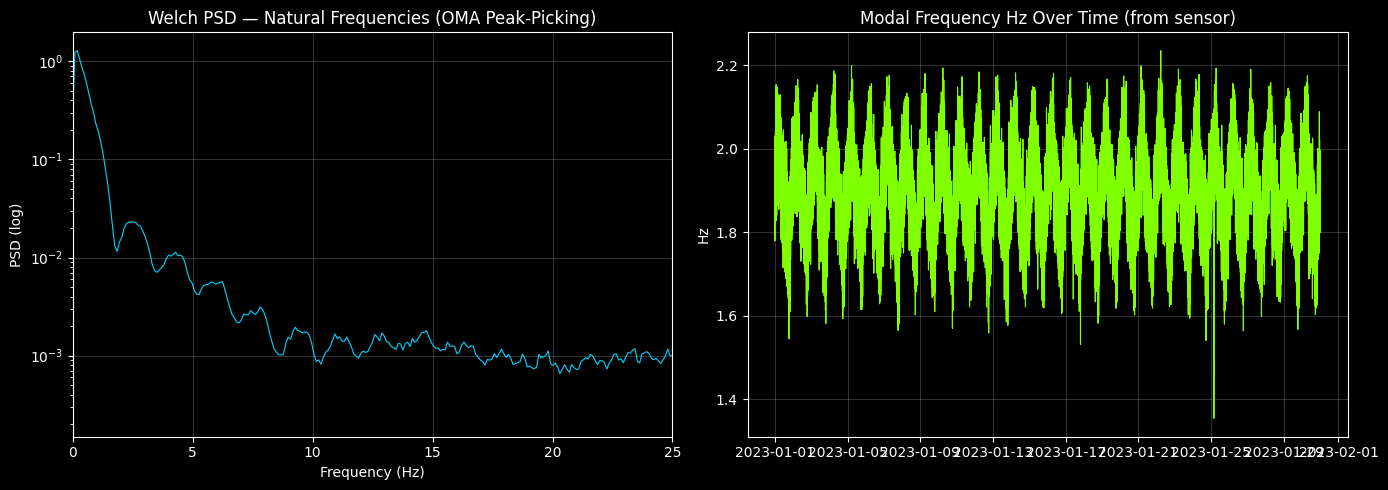

✅ OMA complete


In [22]:
# ─── SSI-lite: Stochastic Subspace Identification via correlation matrices ────
# Simplified OMA: estimate natural frequencies from PSD peak-picking
# Reference: Polymax / PLSCF concept

def oma_peak_picking(sig, fs=100, nperseg=1024, min_freq=0.5, max_freq=20):
    """
    Simplified OMA: estimate modal frequencies via Welch PSD peak-picking.
    Returns identified natural frequencies.
    """
    freqs, psd = signal.welch(sig - sig.mean(), fs=fs, nperseg=nperseg)
    
    # Mask to engineering range
    mask = (freqs >= min_freq) & (freqs <= max_freq)
    f_range = freqs[mask]
    p_range = psd[mask]
    
    # Find peaks
    peaks, props = signal.find_peaks(p_range, height=np.percentile(p_range, 75),
                                      distance=5, prominence=0.1*p_range.max())
    natural_freqs = f_range[peaks]
    return freqs, psd, natural_freqs

def track_modal_shift(dt_df, vib_col='Vibration_ms2', fs=100, window_days=7):
    """
    Track dominant natural frequency over rolling windows.
    Frequency shift = structural stiffness change indicator.
    """
    dt_sorted = dt_df.set_index('Timestamp').sort_index()
    vib = dt_sorted[vib_col].dropna()
    
    freq_history = []
    timestamps   = []
    window_size  = int(fs * 60 * 60)  # 1 hour samples
    step_size    = window_size // 4
    vals = vib.values
    t    = vib.index
    
    for start in range(0, len(vals) - window_size, step_size):
        window = vals[start:start+window_size]
        freqs, psd, nat_freqs = oma_peak_picking(window, fs=fs)
        dominant = nat_freqs[0] if len(nat_freqs) > 0 else np.nan
        freq_history.append(dominant)
        timestamps.append(t[start + window_size//2])
    
    return pd.Series(freq_history, index=timestamps, name='dominant_natural_freq')

# Apply OMA on full vibration signal
vib_signal = dt.set_index('Timestamp')['Vibration_ms2'].dropna()
fs_est = 100  # assume 100 Hz if not specified

freqs, psd, nat_freqs = oma_peak_picking(vib_signal.values, fs=fs_est)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(freqs, psd, color=PALETTE[0], linewidth=0.8)
for f in nat_freqs:
    axes[0].axvline(f, color='yellow', alpha=0.8, linestyle='--', linewidth=1.2)
axes[0].set_xlim(0, 25)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('PSD (log)')
axes[0].set_title('Welch PSD — Natural Frequencies (OMA Peak-Picking)')
axes[0].grid(alpha=0.2)
print(f'Identified natural frequencies: {nat_freqs.round(2)} Hz')

# Modal frequency tracked over time (if dataset big enough)
if 'Modal_Frequency_Hz' in dt.columns:
    dt_plot = dt.set_index('Timestamp')['Modal_Frequency_Hz'].dropna()
    axes[1].plot(dt_plot.index, dt_plot.values, color=PALETTE[2], linewidth=0.8)
    axes[1].set_title('Modal Frequency Hz Over Time (from sensor)')
    axes[1].set_ylabel('Hz')
    axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('figures/oma_modal.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ OMA complete')

## Export Models
Exporting pipelines for Risk Prediction.

In [23]:
import joblib
import torch
import os
os.makedirs('models', exist_ok=True)
try:
    if 'scaler_anom' in locals() and 'iso_forest' in locals():
        joblib.dump(scaler_anom, 'models/scaler_anomaly.pkl')
        joblib.dump(iso_forest, 'models/isolation_forest.pkl')
        print("Successfully exported StandardScaler and IsolationForest.")
except Exception as e:
    print("Error exporting models:", e)


Successfully exported StandardScaler and IsolationForest.
